# 📊 Сравнение алгоритмов поиска пути

В этом ноутбуке проводится экспериментальное сравнение алгоритмов поиска пути на случайно генерируемых гауссовых полях.

## Описание проекта

### 🎯 Цель исследования

Сравнить следующие алгоритмы:

- A*
- Дейкстра
- Жадный (Greedy)

по следующим метрикам:

- время выполнения
- количество посещённых и обработанных узлов
- длина найденного пути (евклидова и пиксельная)
- успешность нахождения пути
- максимальные углы в пути (вбок и продольный)
- минимальные расстояния до препятсвия (евклидово и пиксельное)

### 🧪 Методология

Для каждого запуска:

1. Генерируется поле фиксированного размера (1000x1000) с гаусами с случайными параметрами в заданых диапозонах.
2. Запускаются все алгоритмы на одной и той же карте.
3. Метрики записываются в CSV файл.
4. Максимально допустимые углы вперед/назад и вбок = 30 градусам
5. Всего 1000 запусков каждого алгоритма

#### 📌 Важно

Все алгоритмы сравниваются **на одинаковых входных данных**, что позволяет делать корректные выводы о производительности и качестве решений.

### Задачи исследования

1. Загрузить библиотеки и таблицу
2. Небольшая очистка/подготовка данных
3. Базовая статистика
- Вывод
4. Парное сравнение
- Собрать парные датасеты (A* vs Dijekstra) и  (A* vs Greedy)
- Насколько A* лучше Dijekstra
- Вывод
- Преимущетсва и недостатки Greedy перед A*
- Вывод

## Ход исследования

### 1) Загрузка библиотек и таблицы

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# путь к CSV
path = "../var/metrics/graph.csv"

df = pd.read_csv(path)

df.head()

,environment,algorithmName,executionTimeMs,pathNodes,expandedNodes,euclideanLength,pixelLength,pathFound,minObstacleDistance,minObstacleDistancePixel,maxSideAngle,maxUpDownAngle
0,graph,A*,0.000798,0,0,0.00,0,0,0,0,0.00000,0.00000
1,graph,Dijkstra,0.000493,0,0,0.00,0,0,0,0,0.00000,0.00000
2,graph,Greedy,0.000421,0,0,0.00,0,0,0,0,0.00000,0.00000
3,graph,A*,0.226902,40,378,1546.76,1333,1,3,3,5.42599,8.48376
4,graph,Dijkstra,0.366957,40,985,1546.76,1333,1,3,3,5.42599,8.48376


In [2]:
graph = df[df["environment"] == "graph"]
success = (
    graph.groupby("algorithmName")["pathFound"]
         .agg(["sum", "count", "mean"])
)

success["success_%"] = success["mean"] * 100
print(success)

               sum  count   mean  success_%
algorithmName                              
A*             903   1000  0.903       90.3
Dijkstra       903   1000  0.903       90.3
Greedy         339   1000  0.339       33.9


### 2) Небольшая очистка/подготовка

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   environment               3000 non-null   object 
 1   algorithmName             3000 non-null   object 
 2   executionTimeMs           3000 non-null   float64
 3   pathNodes                 3000 non-null   int64  
 4   expandedNodes             3000 non-null   int64  
 5   euclideanLength           3000 non-null   float64
 6   pixelLength               3000 non-null   int64  
 7   pathFound                 3000 non-null   int64  
 8   minObstacleDistance       3000 non-null   int64  
 9   minObstacleDistancePixel  3000 non-null   int64  
 10  maxSideAngle              3000 non-null   float64
 11  maxUpDownAngle            3000 non-null   float64
dtypes: float64(4), int64(6), object(2)
memory usage: 281.4+ KB


In [4]:
# приводим типы (на всякий случай)
df["executionTimeMs"] = df["executionTimeMs"].astype(float)
df["expandedNodes"] = df["expandedNodes"].astype(int)
df["pathNodes"] = df["pathNodes"].astype(int)
df["pathFound"] = df["pathFound"].astype(int)

df["euclideanLength"] = df["euclideanLength"].astype(float)
df["pixelLength"] = df["pixelLength"].astype(int)

df["minObstacleDistance"] = df["minObstacleDistance"].astype(float)
df["minObstacleDistancePixel"] = df["minObstacleDistancePixel"].astype(int)
df["maxSideAngle"] = df["maxSideAngle"].astype(float)
df["maxUpDownAngle"] = df["maxUpDownAngle"].astype(float)

In [5]:
# разделяем по алгоритмам
astar = graph[graph["algorithmName"] == "A*"].reset_index(drop=True)
dijkstra = graph[graph["algorithmName"] == "Dijkstra"].reset_index(drop=True)
greedy = graph[graph["algorithmName"] == "Greedy"].reset_index(drop=True)

# проверяем что строки совпадают по run-логике
n = min(len(astar), len(dijkstra), len(greedy))

astar = astar.iloc[:n]
dijkstra = dijkstra.iloc[:n]
greedy = greedy.iloc[:n]

In [6]:
mask = (
    (astar["pathFound"] == 1) &
    (dijkstra["pathFound"] == 1) &
    (greedy["pathFound"] == 1)
)

astar = astar[mask].reset_index(drop=True)
dijkstra = dijkstra[mask].reset_index(drop=True)
greedy = greedy[mask].reset_index(drop=True)

In [7]:
graph_ok = pd.concat([astar, dijkstra, greedy], ignore_index=True)

### 3) Базовая статистика


=========== executionTimeMs ===========
                mean  median    std    min    max
algorithmName                                    
A*             0.296   0.282  0.082  0.108  0.978
Dijkstra       0.399   0.383  0.078  0.339  0.956
Greedy         0.018   0.016  0.007  0.010  0.063


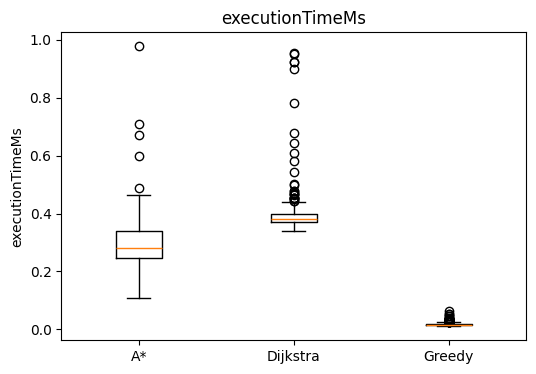


=========== expandedNodes ===========
                   mean  median      std  min   max
algorithmName                                      
A*              469.053   473.0  101.519  149   756
Dijkstra       1002.897  1003.0   23.541  924  1064
Greedy           53.537    53.0    8.518   28    75


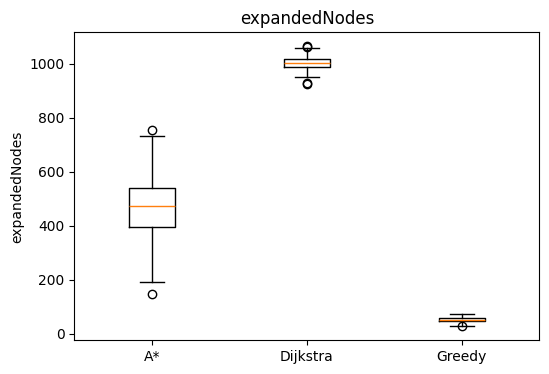


=========== pathNodes ===========
                 mean  median    std  min  max
algorithmName                                 
A*             53.139    53.0  8.317   24   71
Dijkstra       53.139    53.0  8.317   24   71
Greedy         54.537    54.0  8.518   29   76


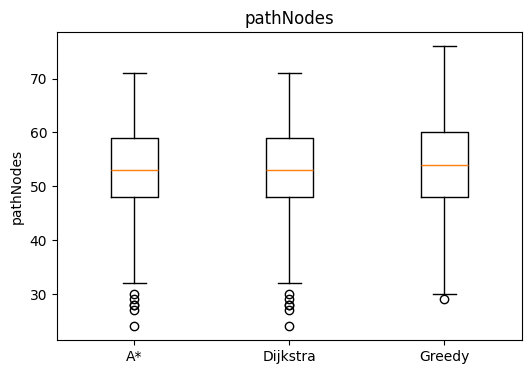


=========== euclideanLength ===========
                   mean   median      std      min      max
algorithmName                                              
A*             1610.229  1609.58   38.950  1482.47  1781.84
Dijkstra       1610.229  1609.58   38.950  1482.47  1781.84
Greedy         1849.231  1828.54  136.691  1561.34  2395.26


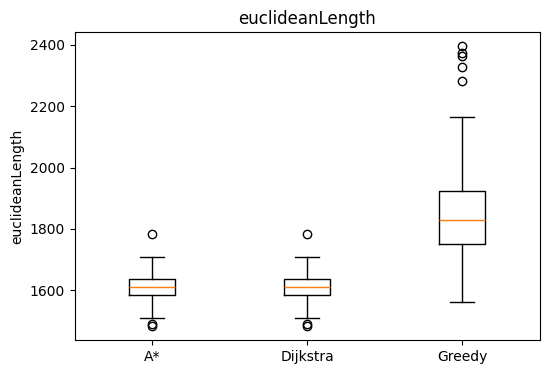


=========== pixelLength ===========
                   mean  median      std   min   max
algorithmName                                       
A*             1476.463  1480.0   67.162  1228  1704
Dijkstra       1476.463  1480.0   67.162  1228  1704
Greedy         1724.740  1710.0  151.272  1336  2291


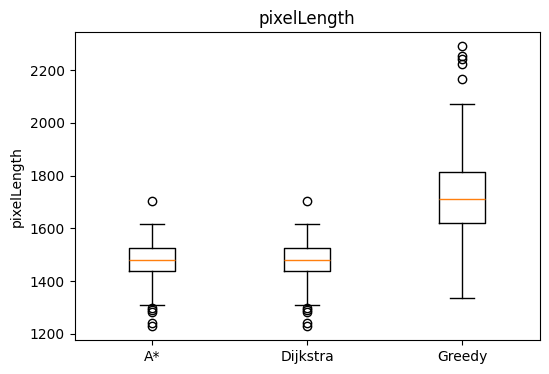


=========== minObstacleDistance ===========
                mean  median    std  min  max
algorithmName                                
A*             2.979     3.0  0.142    2    3
Dijkstra       2.979     3.0  0.142    2    3
Greedy         2.956     3.0  0.206    2    3


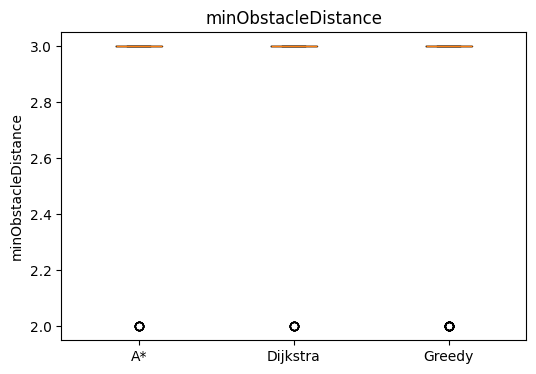


=========== minObstacleDistancePixel ===========
                mean  median    std  min  max
algorithmName                                
A*             2.979     3.0  0.142    2    3
Dijkstra       2.979     3.0  0.142    2    3
Greedy         2.956     3.0  0.206    2    3


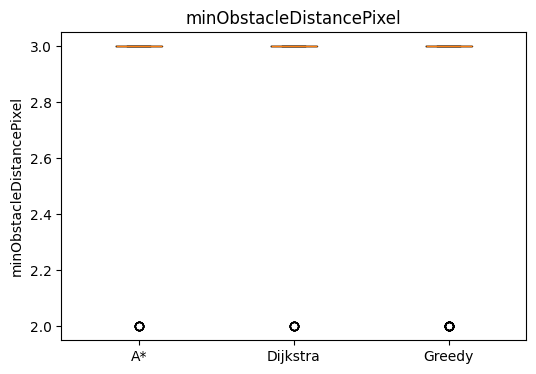


=========== maxSideAngle ===========
                 mean  median    std    min     max
algorithmName                                      
A*             14.054  13.314  6.927  0.407  29.787
Dijkstra       14.054  13.314  6.927  0.407  29.787
Greedy         15.622  15.669  7.025  0.570  29.956


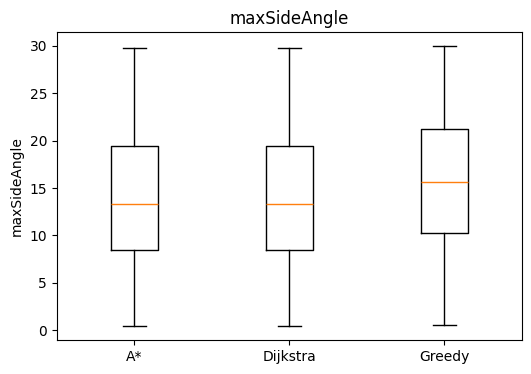


=========== maxUpDownAngle ===========
                 mean  median    std    min     max
algorithmName                                      
A*             12.668  11.437  7.363  0.662  29.849
Dijkstra       12.668  11.437  7.363  0.662  29.849
Greedy         13.595  13.347  6.669  0.574  29.849


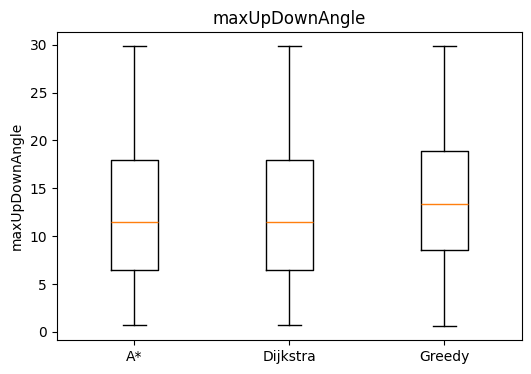

In [8]:
metrics = [
    "executionTimeMs",
    "expandedNodes",
    "pathNodes",
    "euclideanLength",
    "pixelLength",
    "minObstacleDistance",
    "minObstacleDistancePixel",
    "maxSideAngle",
    "maxUpDownAngle"
]

for metric in metrics:
    print(f"\n\033[1m=========== {metric} ===========\033[0m")

    summary = (
        graph_ok.groupby("algorithmName")[metric]
          .agg(["mean", "median", "std", "min", "max"])
          .round(3)
    )

    print(summary)
    plt.figure(figsize=(6, 4))

    plt.boxplot([
        astar[metric],
        dijkstra[metric],
        greedy[metric]
    ], tick_labels=["A*", "Dijkstra", "Greedy"])

    plt.title(metric)
    plt.ylabel(metric)

    plt.show()

#### Вывод

Базовая статистика подтверждает ожидаемые свойства исследуемых алгоритмов. Алгоритмы A* и Дейкстры демонстрируют практически идентичные характеристики построенных маршрутов: число вершин пути, его евклидова и пиксельная длины совпадают во всех проведённых экспериментах. Это свидетельствует о том, что оба метода находят одинаковые пути на заданном навигационном графе, различаясь лишь стратегией поиска. При этом A* достигает результата за существенно меньшее время и с меньшим числом расширенных вершин благодаря использованию эвристической функции, что подтверждает его вычислительную эффективность по сравнению с полным обходом в алгоритме Дейкстры.

Жадный алгоритм демонстрирует наименьшее время работы и минимальное число обработанных вершин, однако это достигается за счёт существенного ухудшения качества и надёжности решения. В среднем он строит более длинные маршруты и значительно чаще не находит путь: успешность поиска составляет порядка 30%, тогда как A* и алгоритм Дейкстры успешно находят путь примерно в 90% случаев на одинаковом наборе тестовых карт.

Поскольку поиск осуществляется на навигационном графе, построенном на основе диаграммы Вороного с учётом ограничений по радиусу тележки и допустимым углам наклона, все алгоритмы формируют геометрически корректные и безопасные маршруты в рамках заданных ограничений. Это подтверждается стабильными значениями минимального расстояния до препятствий и ограниченными значениями максимальных углов на всех успешных траекториях.

Таким образом, уже на этапе базовой статистики наблюдается характерный компромисс между скоростью поиска, качеством найденного маршрута и полнотой поиска. Количественная оценка этих различий будет выполнена в следующем разделе с использованием парного сравнения алгоритмов.

### 4) Парное сравнение

#### A* vs Dijekstra

Смотрим отношения врмени и обработанных вершин (остальные метрики у них совпадают)

In [9]:
time_ratio = (
    dijkstra["executionTimeMs"].to_numpy()
    / astar["executionTimeMs"].to_numpy()
)

expanded_ratio = (
    dijkstra["expandedNodes"].to_numpy()
    / astar["expandedNodes"].to_numpy()
)

comparison = pd.DataFrame({
    "Time ratio": time_ratio,
    "Expanded nodes ratio": expanded_ratio
})

comparison.agg(["mean", "median", "std", "min", "max"]).round(3)

,Time ratio,Expanded nodes ratio
mean,1.437,2.257
median,1.388,2.127
std,0.472,0.604
min,0.435,1.407
max,4.810,6.933


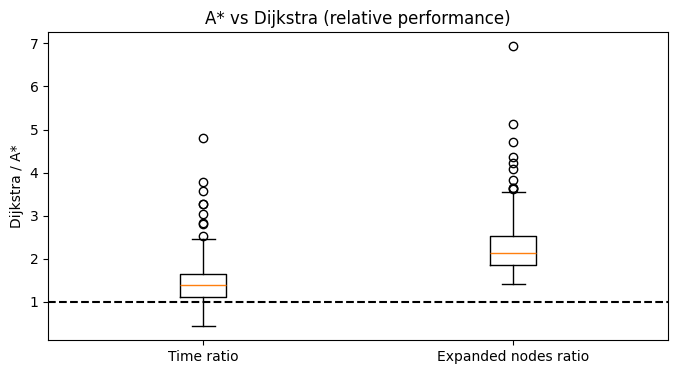

In [10]:
plt.figure(figsize=(8, 4))

plt.boxplot(
    [time_ratio, expanded_ratio],
    tick_labels=["Time ratio", "Expanded nodes ratio"]
)

plt.axhline(1.0, linestyle="--", color="black")

plt.title("A* vs Dijkstra (relative performance)")
plt.ylabel("Dijkstra / A*")

plt.show()

##### Вывод (A* vs Dijkstra)

Парное сравнение алгоритмов показывает устойчивое преимущество A* над алгоритмом Дейкстры по времени выполнения и количеству расширенных вершин при сохранении идентичного качества найденного пути.

По времени работы A* в среднем оказывается быстрее примерно в 1.5 раза, при этом наблюдается умеренный разброс значений, что указывает на зависимость ускорения от структуры конкретного графа.

Более выраженный эффект наблюдается по числу расширенных вершин: A* в среднем исследует в 2 раза меньше узлов, чем алгоритм Дейкстры. Это подтверждает эффективность эвристической компоненты в сокращении пространства поиска.

Таким образом, A* демонстрирует систематическое снижение вычислительных затрат при сохранении оптимальности решения, а выигрыш особенно заметен в метрике числа расширенных состояний, что согласуется с теоретическими свойствами алгоритма.

#### A* vs Greedy

Подготовка метрик


=== time_ratio ===
mean      0.064
median    0.059
std       0.023
min       0.015
max       0.213
Name: time_ratio, dtype: float64


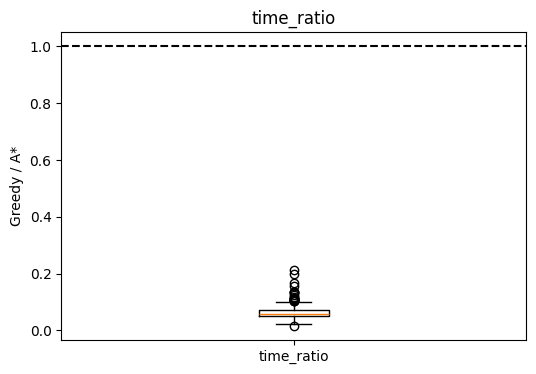


=== expandedNodes_ratio ===
mean      0.119
median    0.114
std       0.029
min       0.065
max       0.247
Name: expandedNodes_ratio, dtype: float64


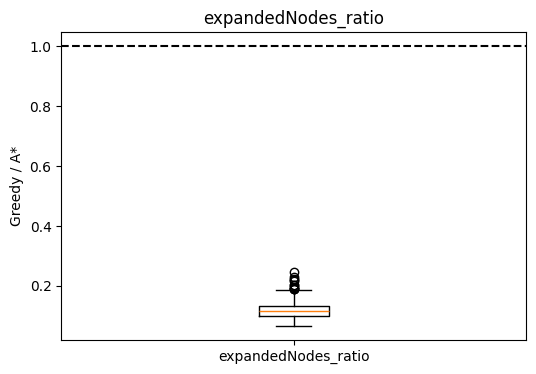


=== path_nodes_ratio ===
mean      1.042
median    1.017
std       0.178
min       0.606
max       1.792
Name: path_nodes_ratio, dtype: float64


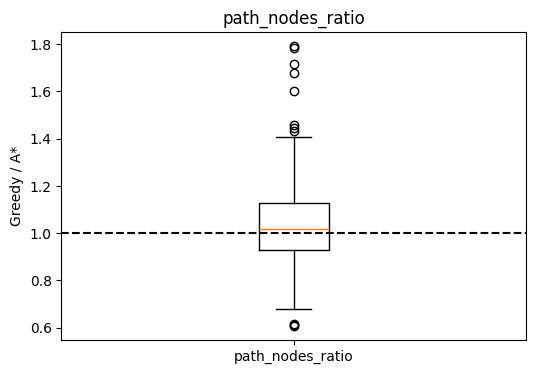


=== euclid_ratio ===
mean      1.148
median    1.138
std       0.079
min       1.012
max       1.516
Name: euclid_ratio, dtype: float64


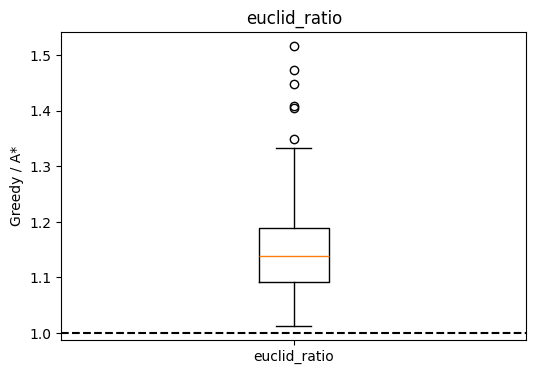


=== pixel_ratio ===
mean      1.168
median    1.153
std       0.089
min       0.996
max       1.542
Name: pixel_ratio, dtype: float64


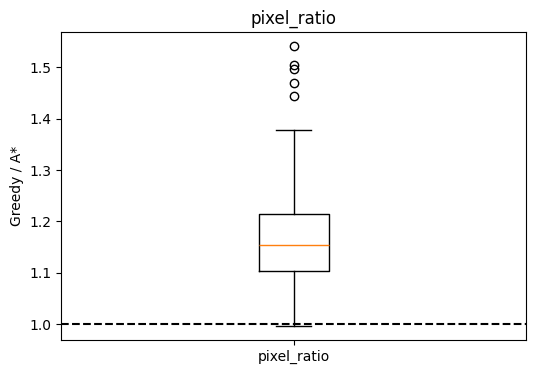


=== minObstacleDistance_ratio ===
mean      0.994
median    1.000
std       0.083
min       0.667
max       1.500
Name: minObstacleDistance_ratio, dtype: float64


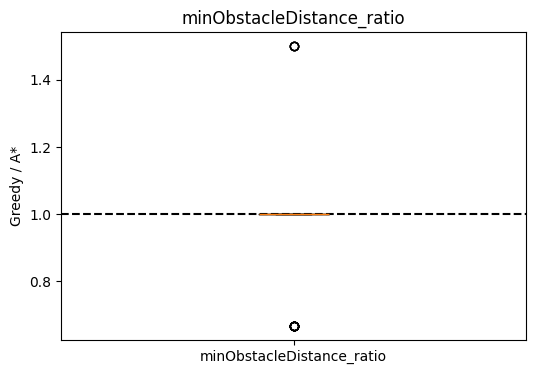


=== minObstacleDistancePixel_ratio ===
mean      0.994
median    1.000
std       0.083
min       0.667
max       1.500
Name: minObstacleDistancePixel_ratio, dtype: float64


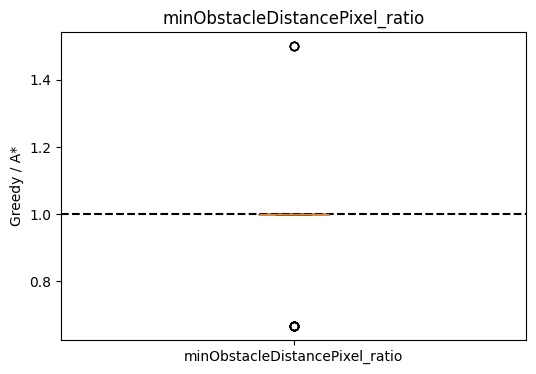


=== maxSideAngle_ratio ===
mean       1.641
median     1.019
std        2.089
min        0.022
max       24.310
Name: maxSideAngle_ratio, dtype: float64


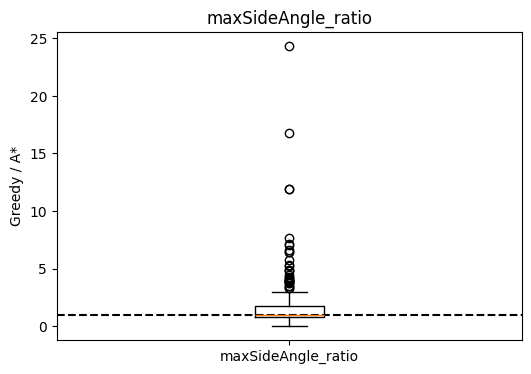


=== maxUpDownAngle_ratio ===
mean       1.751
median     1.000
std        2.207
min        0.032
max       19.426
Name: maxUpDownAngle_ratio, dtype: float64


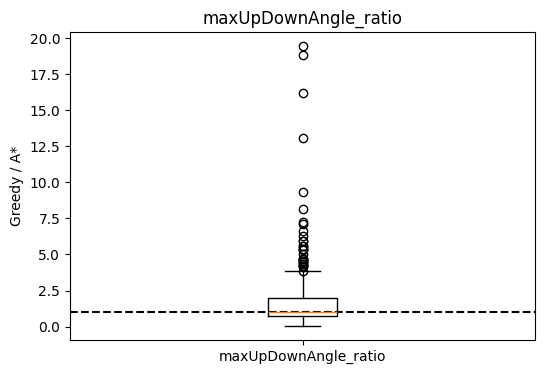

In [12]:
ratios = {
    "time_ratio": greedy["executionTimeMs"].to_numpy() / astar["executionTimeMs"].to_numpy(),
    "expandedNodes_ratio": greedy["expandedNodes"].to_numpy() / astar["expandedNodes"].to_numpy(),
    "path_nodes_ratio": greedy["pathNodes"].to_numpy() / astar["pathNodes"].to_numpy(),
    "euclid_ratio": greedy["euclideanLength"].to_numpy() / astar["euclideanLength"].to_numpy(),
    "pixel_ratio": greedy["pixelLength"].to_numpy() / astar["pixelLength"].to_numpy(),
    "minObstacleDistance_ratio": greedy["minObstacleDistance"].to_numpy() / astar["minObstacleDistance"].to_numpy(),
    "minObstacleDistancePixel_ratio": greedy["minObstacleDistancePixel"].to_numpy() / astar["minObstacleDistancePixel"].to_numpy(),
    "maxSideAngle_ratio": greedy["maxSideAngle"].to_numpy() / astar["maxSideAngle"].to_numpy(),
    "maxUpDownAngle_ratio": greedy["maxUpDownAngle"].to_numpy() / astar["maxUpDownAngle"].to_numpy(),
}

ratio_df = pd.DataFrame(ratios)

for name in ratio_df.columns:
    print(f"\n\033[1m=== {name} ===\033[0m")

    summary = ratio_df[name].agg(["mean", "median", "std", "min", "max"]).round(3)
    print(summary)

    plt.figure(figsize=(6, 4))

    plt.boxplot([ratio_df[name]], tick_labels=[name])
    plt.axhline(1.0, linestyle="--", color="black")

    plt.title(name)
    plt.ylabel("Greedy / A*")

    plt.show()

##### Вывод (Greedy vs A*)

Парное сравнение алгоритмов Greedy и A* демонстрирует выраженный компромисс между вычислительной эффективностью и качеством решения.

По времени выполнения Greedy существенно превосходит A*, обеспечивая ускорение в среднем примерно в 15–20 раз (среднее отношение времени ≈ 0.064). Аналогичная тенденция наблюдается и по числу обработанных вершин: Greedy рассматривает в среднем лишь около 12% от количества узлов, обрабатываемых A*, что подтверждает его значительно меньшую вычислительную сложность.

Однако это ускорение достигается ценой ухудшения качества найденного маршрута. Длина пути, построенного Greedy, в среднем увеличивается примерно на 14–17% (средние значения коэффициентов для евклидовой и пиксельной длины составляют ≈ 1.15–1.17). При этом наблюдается заметная вариативность результатов, что указывает на высокую зависимость качества решения от локальной структуры графа.

Отдельно следует отметить, что Greedy не гарантирует полноту поиска: в части экспериментов алгоритм не смог найти путь, тогда как A* успешно находил корректное решение в подавляющем большинстве случаев. Это подчёркивает фундаментальное отличие эвристического жадного поиска от алгоритма, сохраняющего баланс между оптимальностью и полнотой.

Интересно, что по геометрическим ограничениям (минимальная дистанция до препятствий и углы наклона) оба алгоритма демонстрируют близкие значения, что объясняется общей структурой навигационного графа и едиными условиями проходимости. Это означает, что различия между алгоритмами проявляются прежде всего в стратегии обхода графа, а не в допустимых конфигурациях траектории.

Таким образом, Greedy демонстрирует максимальную скорость работы и минимальные вычислительные затраты, но проигрывает по надёжности и качеству маршрута. В отличие от него, A* обеспечивает более устойчивые и качественные решения за счёт увеличенных вычислительных затрат.